# Etapa 2: Modelado con Validación Segura

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                             roc_curve, accuracy_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/heart.csv")

df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 
                                          'RestingECG', 'ExerciseAngina', 
                                          'ST_Slope'])

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (734, 20)
X_test:  (184, 20)


In [3]:
# Pipeline con RandomForest (el mejor modelo según el ranking en la primera etapa)
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_features": [3, 5, 7]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor AUC en CV:   ", round(grid.best_score_, 3))

Mejores parámetros: {'clf__max_features': 3, 'clf__n_estimators': 100}
Mejor AUC en CV:    0.925


In [5]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print("EVALUACIÓN")
print(f"AUC:      {roc_auc_score(y_test, y_proba):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, 
      target_names=["Sin enfermedad", "Con enfermedad"]))

EVALUACIÓN
AUC:      0.938
Accuracy: 0.864

Reporte de clasificación:
                precision    recall  f1-score   support

Sin enfermedad       0.83      0.84      0.84        77
Con enfermedad       0.89      0.88      0.88       107

      accuracy                           0.86       184
     macro avg       0.86      0.86      0.86       184
  weighted avg       0.86      0.86      0.86       184



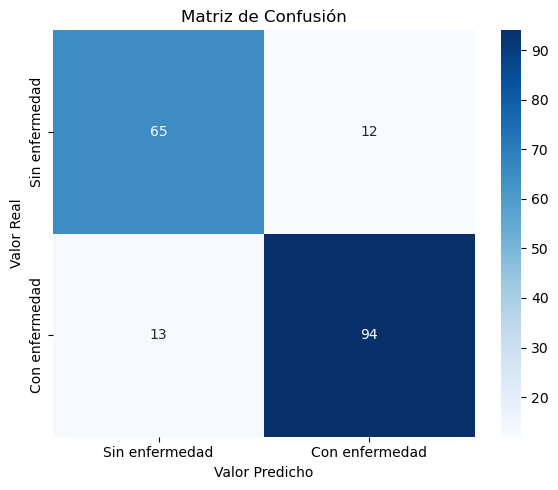

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Sin enfermedad", "Con enfermedad"],
            yticklabels=["Sin enfermedad", "Con enfermedad"])
plt.title("Matriz de Confusión")
plt.ylabel("Valor Real")
plt.xlabel("Valor Predicho")
plt.tight_layout()
plt.savefig('../notebooks/matriz_confusion.png')
plt.show()

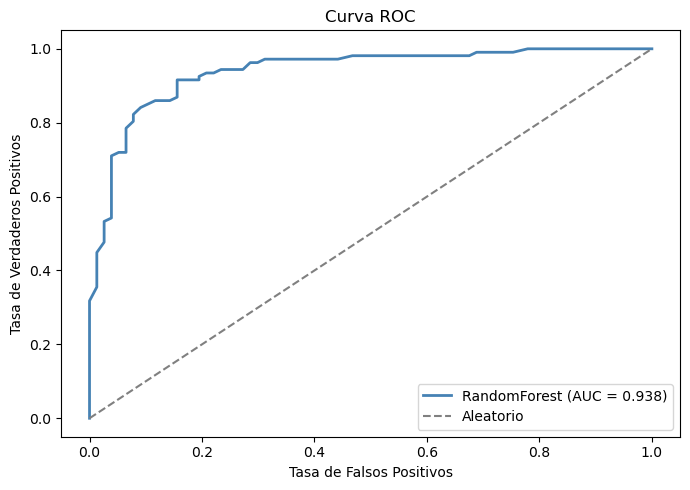

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'RandomForest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/curva_roc.png')
plt.show()

In [9]:
import joblib
joblib.dump(grid.best_estimator_, '../model.joblib')
print("Modelo guardado como model.joblib")

Modelo guardado como model.joblib
